# Was Crypto investing Profitable in Early 2026?
## Analysis of Top 5 most popular Cryptocurrencies: January — April 2026

**Research question:** If an investor bought top 5 cryptocurrencies in January 2026 and sold in April — did they make money or lose it?

**Data:** CoinGecko API, 5 coins, ~120 days

**Tools:** Python, pandas, matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('crypto_2026.csv')
df['date'] = pd.to_datetime(df['date'])
print(df.shape)
df.head()

(605, 3)


,date,coin,price
0,2026-01-11,bitcoin,90442.019078
1,2026-01-12,bitcoin,90819.365989
2,2026-01-13,bitcoin,91134.969180
3,2026-01-14,bitcoin,95260.442297
4,2026-01-15,bitcoin,97007.780789


## Section 1 — Data Overview

In [3]:
df.groupby('coin')['price'].agg(['count', 'min', 'max', 'mean']).round(2)

,count,min,max,mean
coin,,,,
binancecoin,121,583.23,949.10,679.62
bitcoin,121,62853.69,97007.78,75011.62
ethereum,121,1820.57,3356.50,2305.70
ripple,121,1.22,2.16,1.50
solana,121,77.74,146.71,94.22


*Here we can see detailed overview for each coin*

## Section 2 - Profitability Analysis

If an investor bought each coin on January 11 and sold on the last available date then would it be profitable for him?

In [10]:
results = []
for coin in df['coin'].unique():
    coin_df = df[df['coin'] == coin]
    buy_price = coin_df['price'].iloc[0]
    sell_price = coin_df['price'].iloc[-1]
    return_pct = ((sell_price - buy_price) / buy_price) * 100
    results.append({
            'coin': coin,
        'buy_price': round(buy_price, 2),
        'sell_price': round(sell_price, 2),
        'return%': round(return_pct, 2)
            })
results_df = pd.DataFrame(results)
results_df

,coin,buy_price,sell_price,return%
0,bitcoin,90442.02,80847.93,-10.61
1,ethereum,3082.97,2330.05,-24.42
2,solana,135.80,93.93,-30.83
3,binancecoin,906.69,650.13,-28.30
4,ripple,2.09,1.43,-31.76


## Section 3 - Visualization
Price dynamics of all 5 coins from January to April 2026

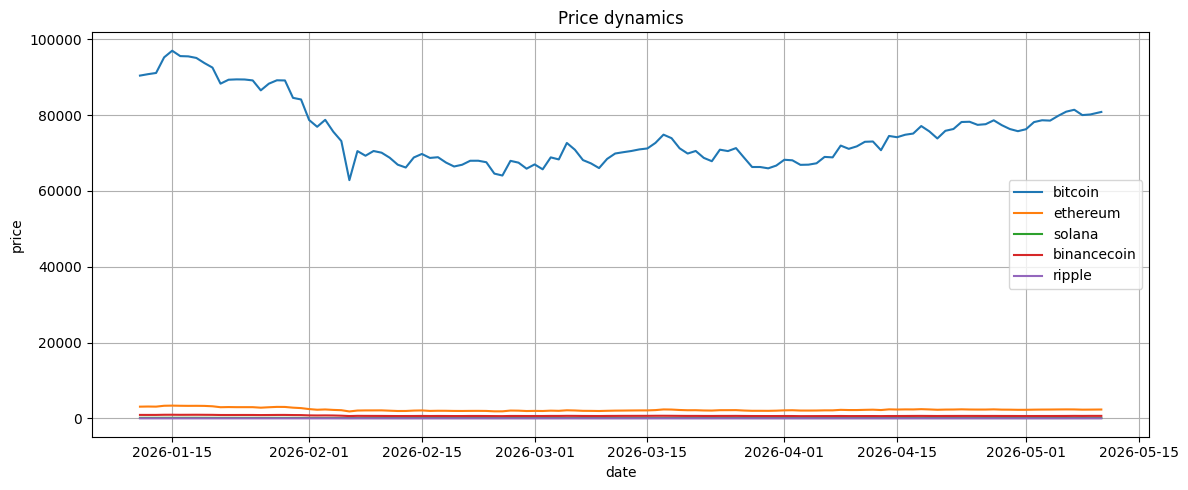

In [12]:
plt.figure(figsize=(12, 5))

for coin in df["coin"].unique():
    coin_df = df[df["coin"] == coin]
    plt.plot(coin_df["date"], coin_df["price"], label=coin)

plt.title('Price dynamics')
plt.xlabel('date')
plt.ylabel('price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## It is clear as a day that bitcoin's price is so high that it's nearly impossible to read a graphic so lets exlude it


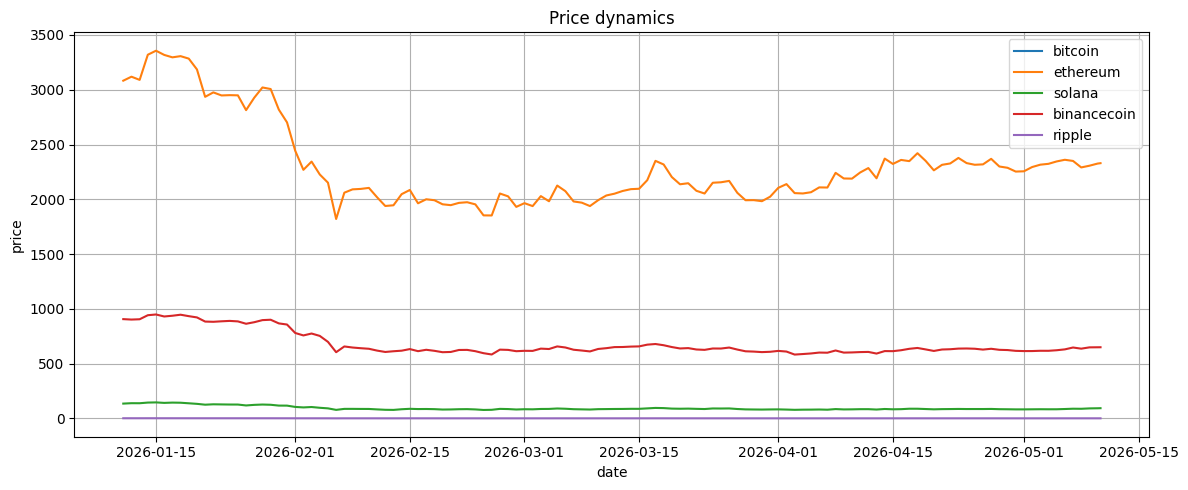

In [16]:
no_bitcoin = df[df['coin'] != 'bitcoin']

plt.figure(figsize=(12, 5))

for coin in df["coin"].unique():
    coin_df = no_bitcoin[no_bitcoin["coin"] == coin]
    plt.plot(coin_df["date"], coin_df["price"], label=coin)

plt.title('Price dynamics')
plt.xlabel('date')
plt.ylabel('price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Chart Insights

**Ethereum** started at ~3,100 USD in January and dropped sharply to ~1,900 USD by early February - a fall of nearly 40% in just 3 weeks. It then stabilized around 2,000-2,300 USD for the rest of the period, showing no significant recovery.

**Binancecoin** followed a similar pattern - dropped from ~950 USD to ~600 USD by February and remained flat through April, showing no signs of recovery.

**Solana** was the weakest performer - started at ~135 USD, dropped to ~80 USD by February and stayed low for the entire period.

**Overall trend:** All three coins peaked in mid-January and experienced their sharpest decline in the first 3 weeks of February. After that, prices stabilized but never recovered to January levels.

## Good now lets do the same trick with the "Ripple" coin and closely see its shifts

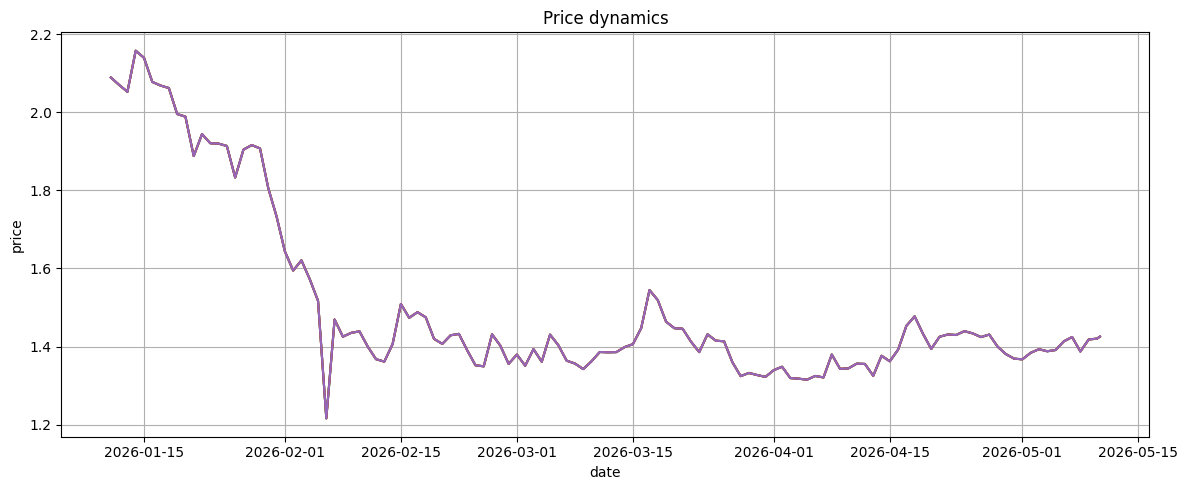

In [20]:


plt.figure(figsize=(12, 5))

for coin in df["coin"].unique():
    coin_df = df[df["coin"] == 'ripple']
    plt.plot(coin_df["date"], coin_df["price"], label=coin)

plt.title('Price dynamics')
plt.xlabel('date')
plt.ylabel('price')
plt.grid(True)
plt.tight_layout()
plt.show()

**Ripple:** As we can see ripple coin started its journey around ~2.1 USD and lost its value almost by 42% in just 3 weeks which significant value. The next week it managed to recover its price to ~1.5 USD and showed only slight changes. Overall, we can say that the ripple coin lost its value by 31% since January and shows non profitable case. 

## Section 4 - First Conclusion

**Research question:** Was crypto investing profitable for these 5 coins in early 2026?

**Answer: No.** All 5 cryptocurrencies declined between January and April 2026.

| Coin | Return |
|------|--------|
| Bitcoin | -10.61% |
| Ethereum | -24.42% |
| Binancecoin | -28.30% |
| Ripple | -31.76% |
| Solana | -30.83% |

**Key findings:**

1. All coins peaked in mid-January 2026 and experienced the sharpest decline in the first 3 weeks of February.
2. Bitcoin was the most resilient coin with the smallest loss of 10.61%.
3. Solana and Ripple were the worst performers with losses above 30%.
4. No coin recovered to its January price level by April 2026.

**Bottom line:** A simple buy-and-hold strategy in early 2026 would have resulted in an average loss of approximately 25% across all major cryptocurrencies.

## Section 5 - New DataSet
## So we currently know price dynamics of our previous 5 coins. But lets find out what coins were actually profitable during this time period?!

To achive this goal I've downloaded a new dataset from CoinGecko of 50 most popular coins. 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df50 = pd.read_csv("crypto_top50.csv")
df50["date"] = pd.to_datetime(df50["date"])

print("coins in dataset:", df50["coin"].nunique())
df50.head()

coins in dataset: 50


,date,coin,price
0,2026-01-12,bitcoin,90819.365989
1,2026-01-13,bitcoin,91134.969180
2,2026-01-14,bitcoin,95260.442297
3,2026-01-15,bitcoin,97007.780789
4,2026-01-16,bitcoin,95584.827979


## Great, now we can move on with calculating returns for other 45 coins. Also let's exclude our first 5 coins from the pool.

Plus for better understanding lets sort our list by descending returns 

In [4]:
old_coins = ["bitcoin", "ethereum", "solana", "binancecoin", "ripple"]
df50_new = df50[~df50["coin"].isin(old_coins)]

results = []

for coin in df50_new["coin"].unique():
    coin_df = df50_new[df50_new["coin"] == coin]
    buy_price = coin_df["price"].iloc[0]
    sell_price = coin_df["price"].iloc[-1]
    return_pct = ((sell_price - buy_price) / buy_price) * 100
    results.append({
        "coin": coin,
        "return_%": round(return_pct, 2)
    })

results50 = pd.DataFrame(results)
results50 = results50.sort_values("return_%", ascending=False)
results50

,coin,return_%
22,memecore,96.11
8,hyperliquid,72.04
9,zcash,50.26
44,sky,33.08
14,the-open-network,32.14
2,tron,17.10
10,leo-token,12.28
29,bittensor,11.91
39,ondo-finance,8.20
5,whitebit,8.01


## Wow! We already can see that some coins are showing good growth and some are losing it. So now let us keep coins that have positive returns 

In [6]:
old_coins = ["bitcoin", "ethereum", "solana", "binancecoin", "ripple"]
df50_new = df50[~df50["coin"].isin(old_coins)]

results = []

for coin in df50_new["coin"].unique():
    coin_df = df50_new[df50_new["coin"] == coin]
    buy_price = coin_df["price"].iloc[0]
    sell_price = coin_df["price"].iloc[-1]
    return_pct = ((sell_price - buy_price) / buy_price) * 100
    results.append({
        "coin": coin,
        "return_%": round(return_pct, 2)
    })

results50 = pd.DataFrame(results)
results50 = results50.sort_values("return_%", ascending=False)
profitable = results50[results50["return_%"] > 0]
profitable

,coin,return_%
22,memecore,96.11
8,hyperliquid,72.04
9,zcash,50.26
44,sky,33.08
14,the-open-network,32.14
2,tron,17.10
10,leo-token,12.28
29,bittensor,11.91
39,ondo-finance,8.20
5,whitebit,8.01


## Now lets see price dynamics for our coins.

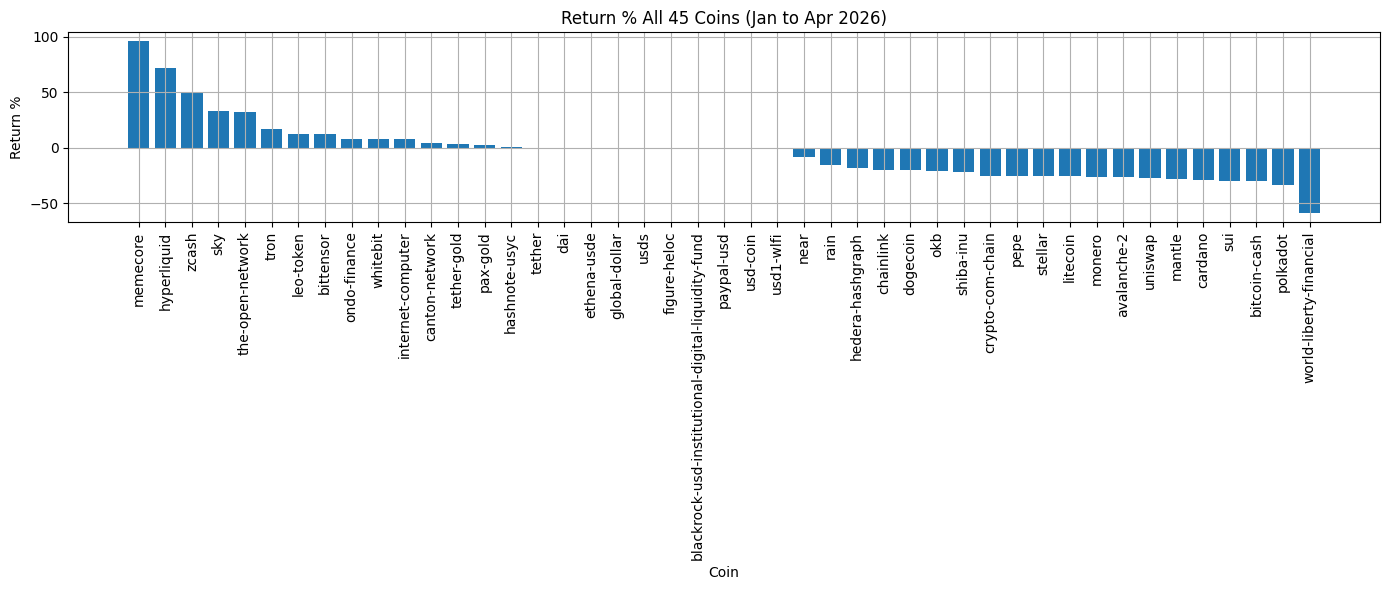

In [10]:
plt.figure(figsize=(14, 6))
plt.bar(results50["coin"], results50["return_%"])
plt.title("Return % All 45 Coins (Jan to Apr 2026)")
plt.xlabel("Coin")
plt.ylabel("Return %")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

**Here we can see how prices changed from Janury value to April's.**

## So we alredy can answer to our question: What coins were profitable for investing in January - April period. Answer: 19 coins showed positive returns. But now lets find out 5 most profitable ones!

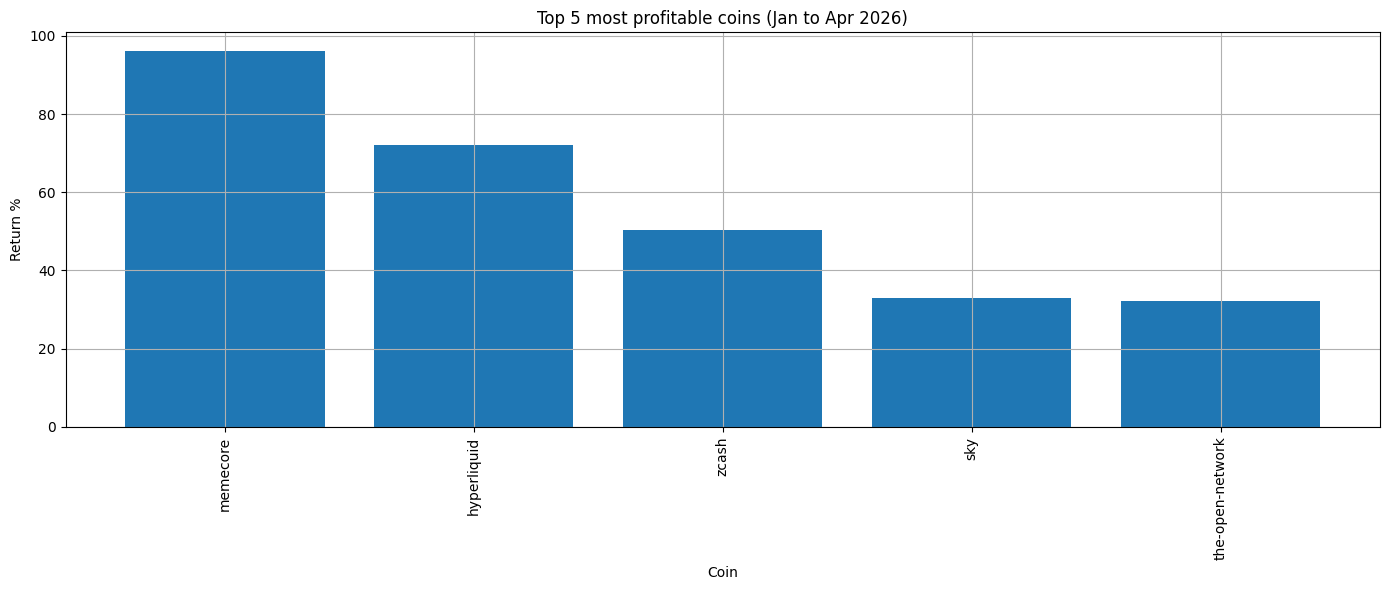

In [13]:
top5 = profitable.head(5)
top5

plt.figure(figsize=(14, 6))
plt.bar(top5["coin"], top5["return_%"])
plt.title("Top 5 most profitable coins (Jan to Apr 2026)")
plt.xlabel("Coin")
plt.ylabel("Return %")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

## Section 6 - Final Conclusion

**Research question:** Which coins were profitable despite the general market downturn in early 2026?

**Answer:** While most cryptocurrencies lost value, 19 out of 45 coins showed positive returns.

**Top 5 most profitable coins:**

| Coin | Return |
|------|--------|
| Memecore | +96.11% |
| Hyperliquid | +72.04% |
| Zcash | +50.26% |
| Sky | +33.08% |
| The Open Network | +32.14% |

**Key insight:** The most profitable coins in early 2026 were not the most popular ones. 
While Bitcoin, Ethereum and Solana all declined by 10-31%, smaller and less known coins 
like Memecore and Hyperliquid delivered strong returns. This suggests that in a bearish 
market, opportunities exist outside the top coins if an investor is willing to take on 
more risk.